In [1]:
import os
import sys
import time
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# ray 관련 라이브러리 임포트
import ray
from ray import tune
from ray.tune.registry import register_env

# 프로젝트 루트 디렉토리 설정
os.chdir("/home/youngjins/project/belief_trading")

# lib 하위 경로 추가
sys.path.append("/home/youngjins/project/belief_trading/lib/")
sys.path.append("/home/youngjins/project/belief_trading/lib/abides_jpmc_public")

# 환경 임포트
import gym
from abides_gym.envs.markets_execution_environment_v0 import (
    SubGymMarketsExecutionEnv_v0,
)

# lib 모듈 임포트
from lib.utils import gym_types, flatten_dict

In [2]:
# 매개 변수 선언
seed = 0
gym_type_str = "markets-execution-v0"

# 함수 init
ray.shutdown()
ray.init()

np.random.seed(seed)

gym_type_abb = gym_types[gym_type_str]

register_env(
    gym_type_str,
    lambda config: SubGymMarketsExecutionEnv_v0(**config),
)

2025-03-17 19:09:45,785	INFO worker.py:1752 -- Started a local Ray instance.


In [3]:
# policy 정의
class policyPassive:
    """
    패시브 정책은 항상 1을 반환 (시장 가격에 영향을 최소화, 소극적으로 주문을 실행하는 전략)
    """

    def __init__(self):
        self.name = "passive"

    def get_action(self, state):
        return 1


class policyAggressive:
    """
    공격적 정책은 항상 0을 반환 (적극적으로 주문을 처리하는 전략, 시장 충격이 클 수 있음)
    """

    def __init__(self):
        self.name = "aggressive"

    def get_action(self, state):
        return 0


class policyRandom:
    """
    무작위 정책은 0과 1 중에서 무작위로 선택 (패시브와 공격적 전략을 무작위로 혼합하는 방식)
    """

    def __init__(self):
        self.name = "random"

    def get_action(self, state):
        return np.random.choice([0, 1])


class policyRandomWithNoAction:
    """
    완전 무작위 정책은 0, 1, 2 중에서 무작위로 선택 (관망하며 시장 상황을 지켜보는 옵션을 포함)
    """

    def __init__(self):
        self.name = "random_no_action"

    def get_action(self, state):
        return np.random.choice([0, 1, 2])

In [4]:
# 강화학습 관련 변수 선언
env = gym.make(
    gym_type_str,
    background_config="rmsc04",
    timestep_duration="10S",
    execution_window="04:00:00",
    parent_order_size=20000,
    order_fixed_size=50,
    not_enough_reward_update=-100,  # penalty
    debug_mode=True
)

env.seed(seed)

target_agent = policyRandomWithNoAction()

In [5]:
# 시뮬레이션 시작
state = env.reset()
done = False
episode_reward = 0

# 데이터 추적을 위한 히스토리 딕셔너리 초기화
history_dict = {
    "mid_price": [],
    "best_bid": [],
    "best_ask": [],
    "reward": [],
    "cumulative_reward": [],
    "pnl": [],
    "holdings": [],
    "time": []
}

# 1개 에피소드 실행 (소요 시간 측정)
start_time = time.time()    
while not done:
    action = target_agent.get_action(state)
    state, reward, done, info = env.step(action)
    episode_reward += reward
    
    # 현재 상태에서 필요한 정보 추출
    mid_price = (info["best_bid"] + info["best_ask"]) / 2  # 중간 가격 계산
    history_dict["mid_price"].append(mid_price)
    history_dict["best_bid"].append(info["best_bid"])
    history_dict["best_ask"].append(info["best_ask"])
    history_dict["reward"].append(reward)
    history_dict["cumulative_reward"].append(episode_reward)
    history_dict["pnl"].append(info["pnl"])
    history_dict["holdings"].append(info["holdings"])
    history_dict["time"].append(info["current_time"])
                
end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")

# could add a few more...
output = flatten_dict(info)
output["episode_reward"] = episode_reward
output["name"] = target_agent.name

Execution time: 29.513410091400146 seconds


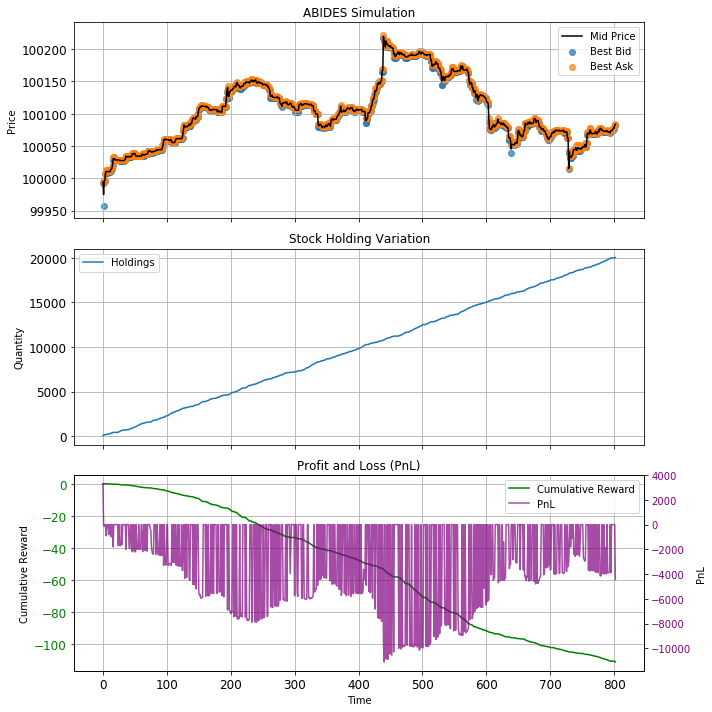

In [16]:
# 그래프 설정
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# 폰트 사이즈 조정
font_size = 12
axes[0].tick_params(labelsize=font_size)
axes[1].tick_params(labelsize=font_size)
axes[2].tick_params(labelsize=font_size)

# 범례 폰트 사이즈 조정
legend_font_size = 10

# 1. 가격 변동 그래프
axes[0].plot(history_dict["mid_price"], label="Mid Price", color="black")
axes[0].scatter(range(len(history_dict["best_bid"])), history_dict["best_bid"], label="Best Bid", alpha=0.7)
axes[0].scatter(range(len(history_dict["best_ask"])), history_dict["best_ask"], label="Best Ask", alpha=0.7)
axes[0].set_title("ABIDES Simulation")
axes[0].set_ylabel("Price")
axes[0].legend()
axes[0].grid(True)

# 2. 보유량 그래프
axes[1].plot(history_dict["holdings"], label="Holdings")
axes[1].set_title("Stock Holding Variation")
axes[1].set_ylabel("Quantity")
axes[1].legend()
axes[1].grid(True)

# 3. 수익 그래프
# 왼쪽 y축은 Cumulative Reward용
axes[2].plot(history_dict["cumulative_reward"], label="Cumulative Reward", color="green")
axes[2].set_title("Profit and Loss (PnL)")
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Cumulative Reward")
axes[2].tick_params(axis='y', labelcolor="green")
axes[2].grid(True)

# 오른쪽 y축은 PnL용
ax2 = axes[2].twinx()
ax2.plot(history_dict["pnl"], label="PnL", color="purple", alpha=0.7)
ax2.set_ylabel("PnL")
ax2.tick_params(axis='y', labelcolor="purple")

# 두 축의 범례를 하나로 합치기
lines1, labels1 = axes[2].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[2].legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.tight_layout()
plt.show()
